Import the required libraries for data analysis and visualization.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# to Display plots inside the notebook
%matplotlib inline

# to Improve plot appearance
sns.set(style="whitegrid")

Load both datasets into Pandas DataFrames.

In [3]:
trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

/tmp/ipykernel_1137/1225836767.py:1: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  trades = pd.read_csv("historical_data.csv")


View the first few rows to understand the datasets.

In [4]:
print("Historical Trader Data")
display(trades.head())

print("\nFear & Greed Data")
display(sentiment.head())


Historical Trader Data


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.003055,1.050000e+15,1.730000e+12



Fear & Greed Data


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


Check the structure, data types, and missing values.


In [5]:
print("Trader Dataset Information")
trades.info()

Trader Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55784 entries, 0 to 55783
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Account           55784 non-null  object 
 1   Coin              55784 non-null  object 
 2   Execution Price   55784 non-null  float64
 3   Size Tokens       55784 non-null  float64
 4   Size USD          55784 non-null  float64
 5   Side              55784 non-null  object 
 6   Timestamp IST     55784 non-null  object 
 7   Start Position    55784 non-null  float64
 8   Direction         55784 non-null  object 
 9   Closed PnL        55784 non-null  float64
 10  Transaction Hash  55784 non-null  object 
 11  Order ID          55783 non-null  float64
 12  Crossed           55783 non-null  object 
 13  Fee               55783 non-null  float64
 14  Trade ID          55783 non-null  float64
 15  Timestamp         55783 non-null  float64
dtypes: float64(9)

In [6]:
print("Sentiment Dataset Information")
sentiment.info()

Sentiment Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [7]:
print("Missing Values in Trader Dataset")
print(trades.isnull().sum())

Missing Values in Trader Dataset
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            1
Crossed             1
Fee                 1
Trade ID            1
Timestamp           1
dtype: int64


In [8]:
print("Missing Values in Sentiment Dataset")
print(sentiment.isnull().sum())

Missing Values in Sentiment Dataset
timestamp         0
value             0
classification    0
date              0
dtype: int64


Generate statistical summaries of the numerical columns.

In [9]:
display(trades.describe())

,Execution Price,Size Tokens,Size USD,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp
count,55784.000000,5.578400e+04,5.578400e+04,5.578400e+04,55784.000000,5.578300e+04,55783.000000,5.578300e+04,5.578300e+04
mean,25826.454340,1.196706e+04,1.291730e+04,9.182188e+03,116.005014,6.224176e+10,2.684658,5.642351e+14,1.734783e+12
std,39572.671015,1.967365e+05,6.589691e+04,6.195091e+05,1528.820640,2.590862e+10,11.491139,3.263369e+14,1.275035e+10
min,0.000010,1.000000e-05,0.000000e+00,-1.433463e+07,-117990.104100,4.064961e+09,-1.175712,0.000000e+00,1.700000e+12
25%,5.240000,2.357625e-01,2.829200e+02,-4.337175e+02,0.000000,5.355947e+10,0.018662,2.810000e+14,1.730000e+12
50%,26.489500,1.000000e+01,1.088630e+03,3.835930e+00,0.000000,6.996442e+10,0.183762,5.640000e+14,1.740000e+12
75%,79972.250000,1.570500e+02,6.162180e+03,1.765292e+03,17.086754,8.404832e+10,1.321630,8.480000e+14,1.740000e+12
max,108410.000000,1.582244e+07,3.921431e+06,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,1.750000e+12


In [10]:
display(sentiment.describe())

,timestamp,value
count,2.644000e+03,2644.000000
mean,1.631899e+09,46.981089
std,6.597967e+07,21.827680
min,1.517463e+09,5.000000
25%,1.574811e+09,28.000000
50%,1.631900e+09,46.000000
75%,1.688989e+09,66.000000
max,1.746164e+09,95.000000


Convert timestamps into readable date format for merging.


In [11]:
# Trader dataset timestamp is in milliseconds
trades["Date"] = pd.to_datetime(trades["Timestamp"], unit="ms").dt.date

In [12]:
# Sentiment dataset already contains date
sentiment["Date"] = pd.to_datetime(sentiment["date"]).dt.date

Merge the trader and sentiment datasets using the Date column.

In [13]:
merged = pd.merge(
    trades,
    sentiment[["Date", "classification", "value"]],
    on="Date",
    how="inner"
)

display(merged.head())


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,classification,value
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.345404,8.950000e+14,1.730000e+12,2024-10-27,Greed,74
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.005600,4.430000e+14,1.730000e+12,2024-10-27,Greed,74
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050431,6.600000e+14,1.730000e+12,2024-10-27,Greed,74
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050043,1.080000e+15,1.730000e+12,2024-10-27,Greed,74
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.003055,1.050000e+15,1.730000e+12,2024-10-27,Greed,74


Check the merged dataset dimensions.


In [14]:
print("Rows:", merged.shape[0])
print("Columns:", merged.shape[1])

Rows: 47670
Columns: 19


Calculate average profit during different market sentiments.


In [15]:
profit_sentiment = merged.groupby("classification")["Closed PnL"].mean().sort_values(ascending=False)

display(profit_sentiment)

,Closed PnL
classification,
Greed,220.360854
Fear,129.817423
Neutral,56.800214
Extreme Greed,26.320044


Visualize average profit for each market sentiment.


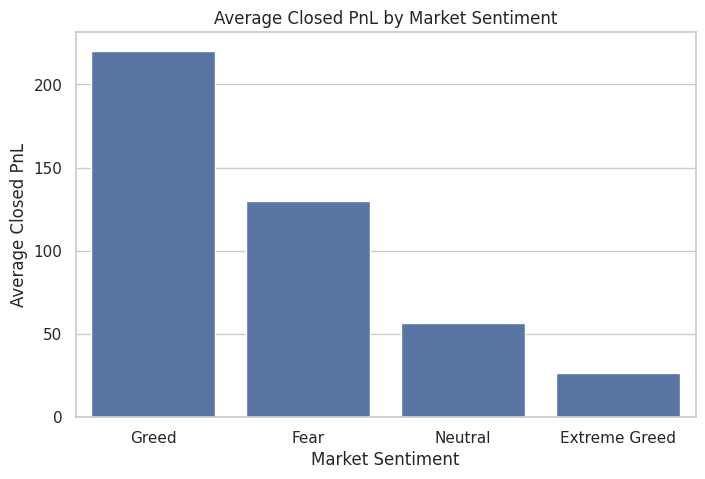

In [16]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=profit_sentiment.index,
    y=profit_sentiment.values
)

plt.title("Average Closed PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")
plt.show()

Analyze average leverage (Start Position) during different sentiments.

In [17]:
leverage_sentiment = merged.groupby("classification")["Start Position"].mean()

display(leverage_sentiment)

,Start Position
classification,
Extreme Greed,70579.509778
Fear,-6808.856730
Greed,22743.060389
Neutral,52102.126629


Compare Buy and Sell trade performance.

In [18]:
side_profit = merged.groupby("Side")["Closed PnL"].mean()

display(side_profit)

,Closed PnL
Side,
BUY,131.129832
SELL,115.326965


Visualize Buy vs Sell profitability.

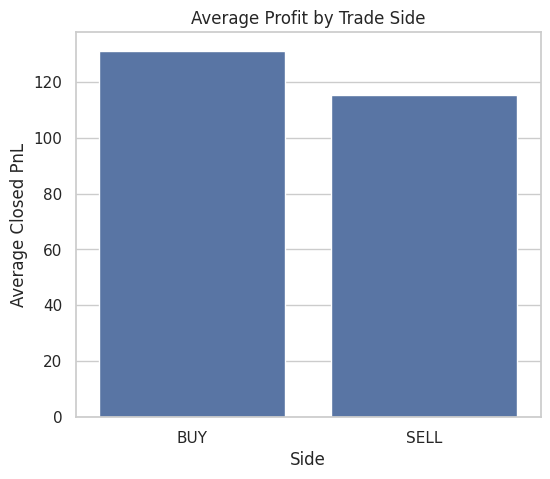

In [19]:
plt.figure(figsize=(6,5))

sns.barplot(
    x=side_profit.index,
    y=side_profit.values
)

plt.title("Average Profit by Trade Side")
plt.xlabel("Side")
plt.ylabel("Average Closed PnL")
plt.show()

Identify the most profitable trading coins.


In [20]:
coin_profit = merged.groupby("Coin")["Closed PnL"].mean().sort_values(ascending=False)

display(coin_profit.head(10))

,Closed PnL
Coin,
ZRO,600.134568
SOL,595.250509
AVAX,508.646946
@109,489.388960
DOGE,429.600329
@107,395.670497
SUI,332.794794
EIGEN,283.828754
ARB,279.686657


Visualize the top 10 most profitable coins.


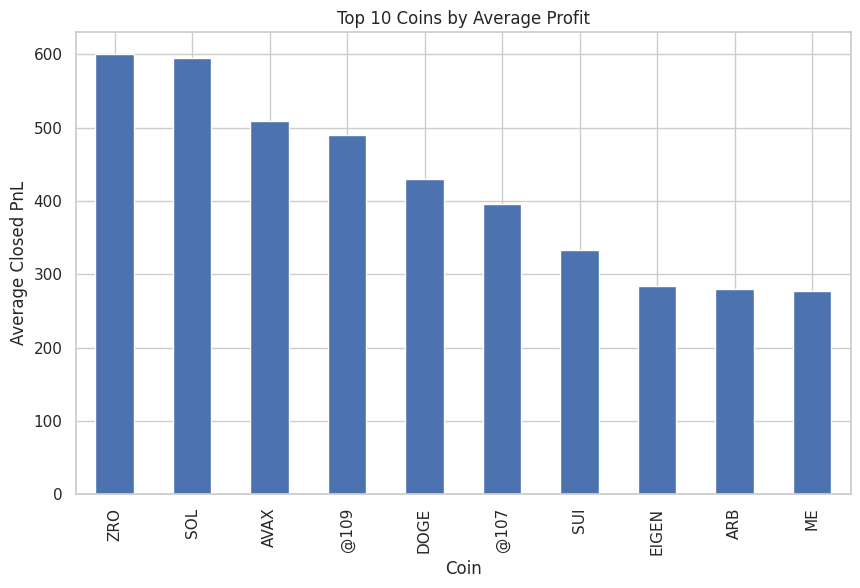

In [21]:
plt.figure(figsize=(10,6))

coin_profit.head(10).plot(kind="bar")

plt.title("Top 10 Coins by Average Profit")
plt.xlabel("Coin")
plt.ylabel("Average Closed PnL")
plt.show()

Identify the top-performing trader accounts.

In [22]:
top_accounts = merged.groupby("Account")["Closed PnL"].sum().sort_values(ascending=False)

display(top_accounts.head(10))

,Closed PnL
Account,
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,2.040922e+06
0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06
0x430f09841d65beb3f27765503d0f850b8bce7713,4.165419e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1,4.035016e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0,3.936830e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,3.615766e+05
0x4f93fead39b70a1824f981a54d4e55b278e9f760,3.012879e+05
0x420ab45e0bd8863569a5efbb9c05d91f40624641,1.995056e+05
0x8381e6d82f1affd39a336e143e081ef7620a3b7f,6.452189e+04


Analyze average trading fees across market sentiments.

In [23]:
fee_analysis = merged.groupby("classification")["Fee"].mean()

display(fee_analysis)

,Fee
classification,
Extreme Greed,0.981814
Fear,2.261329
Greed,2.390447
Neutral,2.386767


Plot the distribution of trader profits.

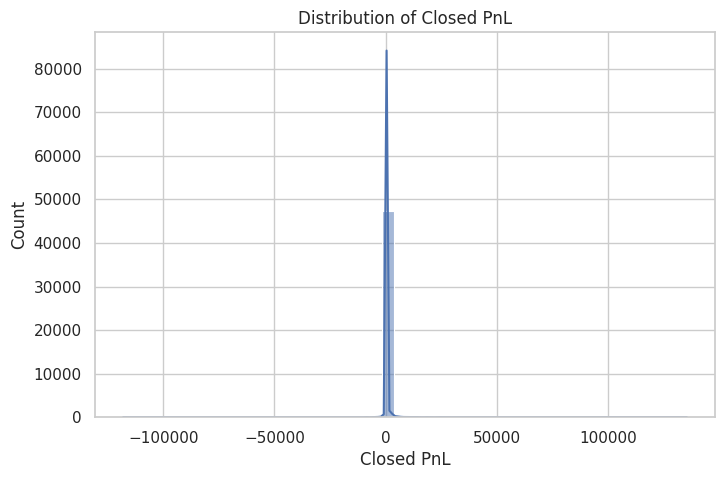

In [24]:
plt.figure(figsize=(8,5))

sns.histplot(
    merged["Closed PnL"],
    bins=50,
    kde=True
)

plt.title("Distribution of Closed PnL")
plt.xlabel("Closed PnL")
plt.show()

Detect outliers in trader profits using a boxplot.

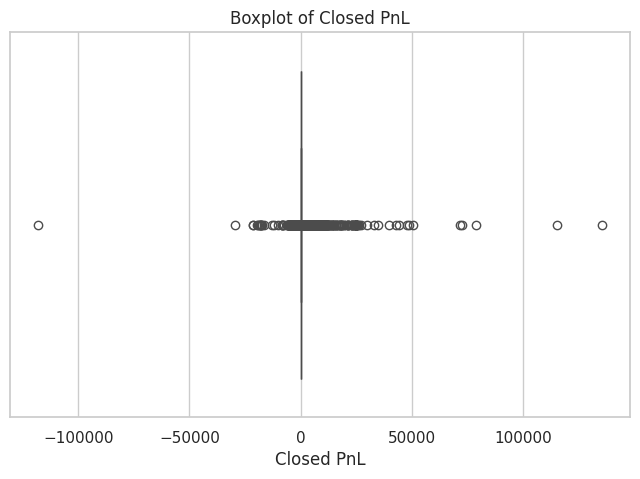

In [25]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=merged["Closed PnL"]
)

plt.title("Boxplot of Closed PnL")
plt.show()

Create a correlation heatmap between numerical variables.

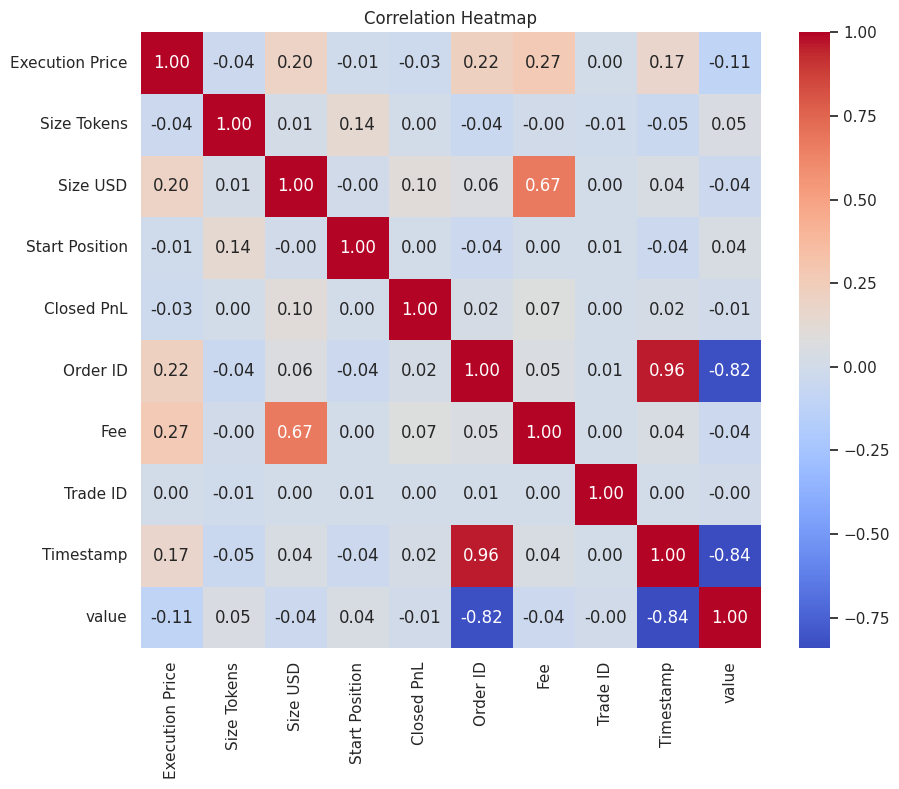

In [26]:
numeric_cols = merged.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

Compare profit distributions across market sentiments.

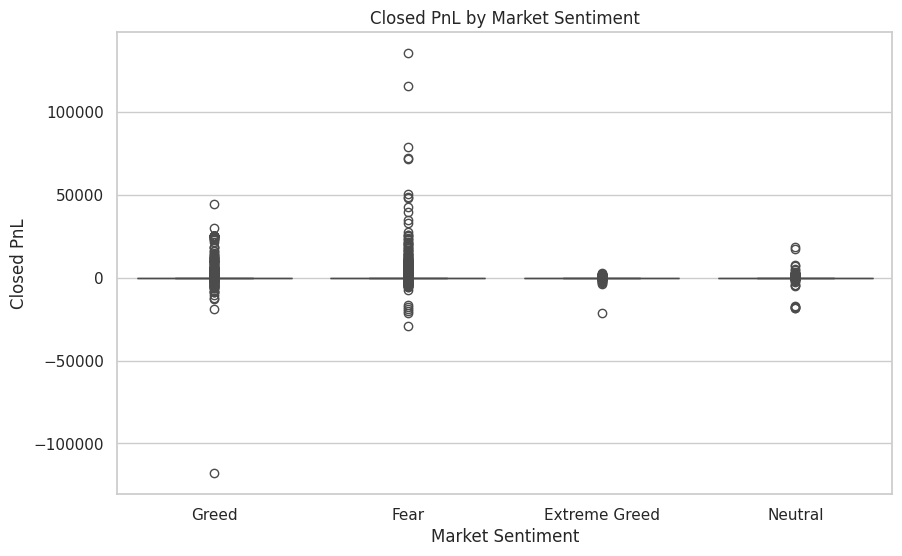

In [27]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=merged,
    x="classification",
    y="Closed PnL"
)

plt.title("Closed PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Closed PnL")
plt.show()

Count the number of trades executed under each market sentiment.

In [28]:
trade_counts = merged["classification"].value_counts()

display(trade_counts)

,count
classification,
Fear,30662
Extreme Greed,6935
Greed,6866
Neutral,3207


Visualize trade counts by market sentiment.

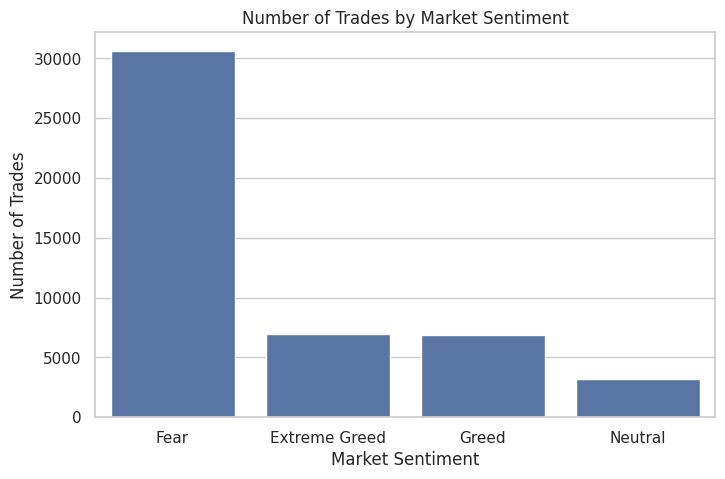

In [29]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=merged,
    x="classification",
    order=merged["classification"].value_counts().index
)

plt.title("Number of Trades by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")
plt.show()